
# GVH Diagonal Cubic 0.2.6 — Strong Field and Null Geodesics
## Champ fort, géodésiques nulles, sphère photonique, ISCO, capture et évasion

**Auteur : Charlemagne O Laurince**

---

## Objectif

Ce notebook prolonge :

- `GVH_Diagonal_Cubic_0.2.1_Metric_Foundations.ipynb`
- `GVH_Diagonal_Cubic_0.2.2_Christoffel_Symbols.ipynb`
- `GVH_Diagonal_Cubic_0.2.3_Geodesic_Integrator.ipynb`
- `GVH_Diagonal_Cubic_0.2.4_Reference_Validation.ipynb`
- `GVH_Diagonal_Cubic_0.2.5_Candidate_Metric_Tests.ipynb`

Il étudie les régimes où la géométrie relativiste produit ses signatures les plus fortes :

1. géodésiques nulles ;
2. déviation et capture de photons ;
3. sphère photonique ;
4. orbites circulaires temporelles ;
5. ISCO ;
6. distinction opérationnelle entre capture, diffusion et évasion ;
7. comparaison Schwarzschild / métrique GVH candidate.

---

## Métrique utilisée

Dans les coordonnées isotropes cartésiennes :

\[
ds^2
=
-A(\rho)c^2dt^2
+
B(\rho)\left(dx^2+dy^2+dz^2\right),
\]

avec

\[
\rho=\sqrt{x^2+y^2+z^2}.
\]

La métrique de Schwarzschild isotrope est :

\[
A_{\mathrm{Schw}}(\chi)
=
\left(
\frac{1-\chi/2}{1+\chi/2}
\right)^2,
\]

\[
B_{\mathrm{Schw}}(\chi)
=
\left(1+\frac{\chi}{2}\right)^4,
\qquad
\chi=\frac{GM}{c^2\rho}.
\]

---

## Statut scientifique

Le candidat GVH polynomial utilisé ici reste exploratoire.  
Une divergence en champ fort ne doit pas être interprétée comme une prédiction tant que :

- la métrique n'est pas dérivée d'un principe GVH ;
- son domaine de validité n'est pas démontré ;
- ses singularités et horizons sont analysés ;
- les tests faibles restent satisfaits.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar, minimize_scalar

np.set_printoptions(precision=12, suppress=True)

G = 6.67430e-11
c = 299_792_458.0
M_SUN = 1.98847e30

# Unités géométriques internes : G = c = M = 1
# Les rayons sont alors exprimés en GM/c^2.

CANDIDATE = {
    "name": "GVH_series_reference_like",
    "a2": 2.0,
    "a3": -1.5,
    "gamma": 1.0,
    "b2": 1.5,
    "b3": 0.5
}

print("Environnement chargé.")


Environnement chargé.



# 1. Fonctions métriques en unités géométriques

On fixe :

\[
G=c=M=1.
\]

Alors :

\[
\chi=\frac{1}{\rho}.
\]

Le rayon aréal associé aux coordonnées isotropes est :

\[
R_{\mathrm{areal}}(\rho)
=
\rho\sqrt{B(\rho)}.
\]

Pour Schwarzschild :

- horizon aréal : \(R=2M\) ;
- sphère photonique : \(R=3M\) ;
- ISCO : \(R=6M\).


In [2]:

def metric_schwarzschild_iso(rho):
    rho = np.asarray(rho, dtype=float)
    if np.any(rho <= 0):
        raise ValueError("rho doit être strictement positif.")
    chi = 1.0/rho
    q = 0.5*chi
    A = ((1.0-q)/(1.0+q))**2
    B = (1.0+q)**4
    return A, B


def metric_gvh_series(rho, params=CANDIDATE):
    rho = np.asarray(rho, dtype=float)
    if np.any(rho <= 0):
        raise ValueError("rho doit être strictement positif.")
    chi = 1.0/rho

    a2 = params["a2"]
    a3 = params["a3"]
    gamma = params["gamma"]
    b2 = params["b2"]
    b3 = params["b3"]

    A = 1.0 - 2.0*chi + a2*chi**2 + a3*chi**3
    B = 1.0 + 2.0*gamma*chi + b2*chi**2 + b3*chi**3
    return A, B


def metric_AB(rho, model="schwarzschild", params=CANDIDATE):
    if model == "schwarzschild":
        return metric_schwarzschild_iso(rho)
    if model == "gvh":
        return metric_gvh_series(rho, params)
    raise ValueError("model doit être 'schwarzschild' ou 'gvh'.")


def areal_radius(rho, model="schwarzschild", params=CANDIDATE):
    _, B = metric_AB(rho, model, params)
    return rho*np.sqrt(B)



# 2. Dérivées numériques stables

Les conditions d'orbites circulaires utilisent les dérivées de \(A\), \(B\) et du rayon aréal.

Nous utilisons une différence centrale adaptative.


In [3]:

def derivative_scalar(func, x, rel_step=1e-5):
    h = max(abs(x)*rel_step, 1e-7)
    if x-h <= 0:
        return (func(x+h)-func(x))/h
    return (func(x+h)-func(x-h))/(2*h)


def second_derivative_scalar(func, x, rel_step=3e-4):
    h = max(abs(x)*rel_step, 1e-6)
    if x-h <= 0:
        return (func(x+2*h)-2*func(x+h)+func(x))/h**2
    return (func(x+h)-2*func(x)+func(x-h))/h**2



# 3. Géodésiques nulles dans le plan équatorial

Pour un photon :

\[
g_{\mu\nu}U^\mu U^\nu=0.
\]

Dans le plan \(z=0\), le vecteur d'état est :

\[
Y=(t,x,y,z,U^t,U^x,U^y,U^z).
\]

Nous générons numériquement les symboles de Christoffel de la métrique isotrope.


In [4]:

def metric_radial_derivatives(rho, model="schwarzschild", params=CANDIDATE):
    fA = lambda rr: metric_AB(rr, model, params)[0]
    fB = lambda rr: metric_AB(rr, model, params)[1]
    return derivative_scalar(fA, rho), derivative_scalar(fB, rho)


def christoffel_numeric(position, model="schwarzschild", params=CANDIDATE):
    pos = np.asarray(position, dtype=float)
    rho = np.linalg.norm(pos)
    if rho <= 0:
        raise ValueError("rho doit être > 0.")

    A, B = metric_AB(rho, model, params)
    dA, dB = metric_radial_derivatives(rho, model, params)

    gradA = dA*pos/rho
    gradB = dB*pos/rho

    Gamma = np.zeros((4,4,4), dtype=float)

    for i in range(3):
        I = i+1
        Gamma[0,0,I] = gradA[i]/(2*A)
        Gamma[0,I,0] = Gamma[0,0,I]
        Gamma[I,0,0] = gradA[i]/(2*B)

    for i in range(3):
        I = i+1
        for j in range(3):
            J = j+1
            for k in range(3):
                K = k+1
                term = 0.0
                if i == k:
                    term += gradB[j]
                if i == j:
                    term += gradB[k]
                if j == k:
                    term -= gradB[i]
                Gamma[I,J,K] = term/(2*B)

    return Gamma


def geodesic_rhs(lam, state, model="schwarzschild", params=CANDIDATE):
    X = state[:4]
    U = state[4:]
    Gamma = christoffel_numeric(X[1:], model, params)

    dX = U.copy()
    dU = np.zeros(4)

    for mu in range(4):
        dU[mu] = -np.einsum("ab,a,b->", Gamma[mu], U, U)

    return np.concatenate([dX, dU])



# 4. Initialisation d'un photon

À une position initiale \(\mathbf x_0\), nous choisissons une direction spatiale unitaire \(\mathbf n\).

La condition nulle donne :

\[
-A(U^t)^2+B\|\mathbf U\|^2=0.
\]

En choisissant \(\|\mathbf U\|=1\) :

\[
U^t=\sqrt{\frac{B}{A}}.
\]


In [5]:

def build_null_state(position, direction, model="schwarzschild", params=CANDIDATE):
    position = np.asarray(position, dtype=float)
    direction = np.asarray(direction, dtype=float)
    direction = direction/np.linalg.norm(direction)

    rho = np.linalg.norm(position)
    A, B = metric_AB(rho, model, params)

    if A <= 0 or B <= 0:
        raise ValueError("Métrique non lorentzienne ou non statique au point initial.")

    Ut = np.sqrt(B/A)
    X0 = np.concatenate([[0.0], position])
    U0 = np.concatenate([[Ut], direction])
    return np.concatenate([X0, U0])


def null_norm(state, model="schwarzschild", params=CANDIDATE):
    X = state[:4]
    U = state[4:]
    rho = np.linalg.norm(X[1:])
    A, B = metric_AB(rho, model, params)
    return -A*U[0]**2 + B*np.dot(U[1:], U[1:])



# 5. Événements : capture, évasion et retour

Nous distinguons opérationnellement :

- **capture** : le rayon franchit une limite interne ;
- **évasion** : il atteint un grand rayon avec vitesse radiale sortante ;
- **diffusion** : il revient vers l'extérieur après un périastre ;
- **indéterminé** : aucun événement avant la fin de l'intégration.

Cette classification reste séparée des équations de mouvement.


In [6]:

def integrate_null_ray(
    impact_parameter,
    model="schwarzschild",
    params=CANDIDATE,
    x_start=-80.0,
    x_end=80.0,
    inner_cut=0.51,
    lambda_max=300.0,
    r_escape=90.0
):
    position0 = np.array([x_start, impact_parameter, 0.0])
    direction0 = np.array([1.0, 0.0, 0.0])
    state0 = build_null_state(position0, direction0, model, params)

    def event_capture(lam, state):
        rho = np.linalg.norm(state[1:4])
        return rho-inner_cut
    event_capture.terminal = True
    event_capture.direction = -1

    def event_escape(lam, state):
        rho = np.linalg.norm(state[1:4])
        pos = state[1:4]
        vel = state[5:8]
        radial = np.dot(pos, vel)/max(rho, 1e-30)
        # événement seulement si sortant
        return rho-r_escape if radial > 0 else -1.0
    event_escape.terminal = True
    event_escape.direction = 1

    sol = solve_ivp(
        lambda lam, y: geodesic_rhs(lam, y, model, params),
        (0.0, lambda_max),
        state0,
        events=[event_capture, event_escape],
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
        max_step=0.05
    )

    if len(sol.t_events[0]) > 0:
        status = "capture"
    elif len(sol.t_events[1]) > 0:
        status = "escape"
    else:
        status = "undetermined"

    return sol, status



# 6. Famille de trajectoires lumineuses

Nous lançons plusieurs photons avec différents paramètres d'impact.

Pour Schwarzschild, le paramètre d'impact critique exact vaut :

\[
b_{\mathrm{crit}}=3\sqrt{3}\,M.
\]

Dans les unités utilisées :

\[
b_{\mathrm{crit}}\approx5.196152.
\]


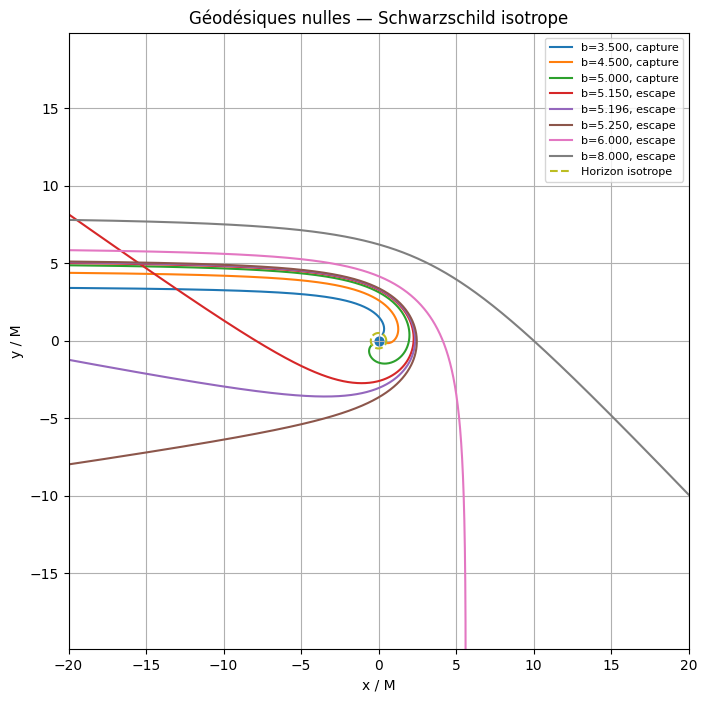

,b,status,rho_min,null_norm_max_abs
0,3.500,capture,0.510000,1.677493e-05
1,4.500,capture,0.510000,1.684793e-05
2,5.000,capture,0.510000,1.675574e-05
3,5.150,escape,2.245314,2.348517e-10
4,5.196,escape,2.355091,2.088587e-10
5,5.250,escape,2.466972,1.968532e-10
6,6.000,escape,3.569735,1.143727e-10
7,8.000,escape,5.871427,7.763279e-11


In [7]:

b_values = [3.5, 4.5, 5.0, 5.15, 5.196, 5.25, 6.0, 8.0]
ray_results = []

plt.figure(figsize=(8,8))

for b in b_values:
    sol, status = integrate_null_ray(b, model="schwarzschild")
    x = sol.y[1]
    y = sol.y[2]
    plt.plot(x, y, label=f"b={b:.3f}, {status}")
    ray_results.append({
        "b": b,
        "status": status,
        "rho_min": np.min(np.linalg.norm(sol.y[1:4].T, axis=1)),
        "null_norm_max_abs": np.max([
            abs(null_norm(sol.y[:,k], "schwarzschild"))
            for k in range(sol.y.shape[1])
        ])
    })

theta = np.linspace(0,2*np.pi,500)
rho_h = 0.5
plt.plot(rho_h*np.cos(theta), rho_h*np.sin(theta), "--", label="Horizon isotrope")
plt.scatter([0],[0],s=40)
plt.xlabel("x / M")
plt.ylabel("y / M")
plt.title("Géodésiques nulles — Schwarzschild isotrope")
plt.axis("equal")
plt.xlim(-20,20)
plt.ylim(-12,12)
plt.grid(True)
plt.legend(fontsize=8)
plt.show()

ray_df = pd.DataFrame(ray_results)
ray_df



# 7. Recherche numérique du paramètre critique de capture

Nous utilisons une bissection opérationnelle entre :

- une trajectoire capturée ;
- une trajectoire échappée.

Le résultat est comparé à :

\[
3\sqrt{3}.
\]


In [8]:

def classify_b(b, model="schwarzschild", params=CANDIDATE):
    _, status = integrate_null_ray(
        b,
        model=model,
        params=params,
        lambda_max=500.0,
        r_escape=100.0
    )
    return status


def find_critical_impact(
    b_low,
    b_high,
    model="schwarzschild",
    params=CANDIDATE,
    iterations=25
):
    low = b_low
    high = b_high

    if classify_b(low, model, params) != "capture":
        raise ValueError("b_low doit être capturé.")
    if classify_b(high, model, params) != "escape":
        raise ValueError("b_high doit s'échapper.")

    history = []

    for _ in range(iterations):
        mid = 0.5*(low+high)
        status = classify_b(mid, model, params)
        history.append((low, mid, high, status))

        if status == "capture":
            low = mid
        elif status == "escape":
            high = mid
        else:
            # proche du seuil : resserrement conservateur
            low = mid

    return 0.5*(low+high), history


bcrit_num, bcrit_history = find_critical_impact(4.5, 6.0)
bcrit_ref = 3*np.sqrt(3)

print("b_crit numérique :", bcrit_num)
print("b_crit analytique :", bcrit_ref)
print("Erreur relative :", abs(bcrit_num-bcrit_ref)/bcrit_ref)


b_crit numérique : 5.068308033049107
b_crit analytique : 5.196152422706632
Erreur relative : 0.024603664261051903



# 8. Sphère photonique par le potentiel optique

Pour une métrique isotrope statique, le paramètre d'impact d'une orbite lumineuse circulaire satisfait :

\[
b^2(\rho)
=
\frac{B(\rho)\rho^2}{A(\rho)}.
\]

La sphère photonique correspond à un extremum :

\[
\frac{d}{d\rho}
\left(
\frac{B\rho^2}{A}
\right)=0.
\]

Nous calculons sa position isotrope et son rayon aréal.


In [9]:

def optical_impact_squared(rho, model="schwarzschild", params=CANDIDATE):
    A, B = metric_AB(rho, model, params)
    return B*rho**2/A


def photon_sphere_equation(rho, model="schwarzschild", params=CANDIDATE):
    return derivative_scalar(
        lambda rr: optical_impact_squared(rr, model, params),
        rho
    )


def find_photon_sphere(model="schwarzschild", params=CANDIDATE, bracket=(0.6, 10.0)):
    grid = np.linspace(bracket[0], bracket[1], 2000)
    vals = np.array([photon_sphere_equation(rr, model, params) for rr in grid])

    roots = []
    for i in range(len(grid)-1):
        if np.isfinite(vals[i]) and np.isfinite(vals[i+1]) and vals[i]*vals[i+1] < 0:
            root = root_scalar(
                lambda rr: photon_sphere_equation(rr, model, params),
                bracket=(grid[i], grid[i+1]),
                method="brentq"
            ).root
            if not roots or abs(root-roots[-1]) > 1e-4:
                roots.append(root)

    return roots


photon_roots_s = find_photon_sphere("schwarzschild")
photon_rows = []

for rho_ph in photon_roots_s:
    R_ph = areal_radius(rho_ph, "schwarzschild")
    b_ph = np.sqrt(optical_impact_squared(rho_ph, "schwarzschild"))
    photon_rows.append({
        "model": "Schwarzschild",
        "rho_photon": rho_ph,
        "R_areal": R_ph,
        "b_critical": b_ph
    })

photon_df = pd.DataFrame(photon_rows)
photon_df


,model,rho_photon,R_areal,b_critical
0,Schwarzschild,1.866025,3.0,5.196152



# 9. Orbites circulaires temporelles

Pour une métrique statique sphérique écrite avec rayon aréal \(R\), les orbites circulaires temporelles peuvent être étudiées via :

\[
E^2(R)
=
\frac{2A(R)^2}
{2A(R)-R\,dA/dR},
\]

\[
L^2(R)
=
\frac{R^3\,dA/dR}
{2A(R)-R\,dA/dR}.
\]

Dans les coordonnées isotropes, nous calculons \(R(\rho)\), puis les dérivées par chaîne.

L'ISCO correspond au minimum de \(L^2\) ou, de manière équivalente, au changement de stabilité des orbites circulaires.


In [10]:

def dA_dR(rho, model="schwarzschild", params=CANDIDATE):
    fA = lambda rr: metric_AB(rr, model, params)[0]
    fR = lambda rr: areal_radius(rr, model, params)
    dA_drho = derivative_scalar(fA, rho)
    dR_drho = derivative_scalar(fR, rho)
    return dA_drho/dR_drho


def circular_EL2(rho, model="schwarzschild", params=CANDIDATE):
    A, _ = metric_AB(rho, model, params)
    R = areal_radius(rho, model, params)
    Ap = dA_dR(rho, model, params)

    denom = 2*A - R*Ap

    if denom <= 0:
        return np.nan, np.nan

    E2 = 2*A*A/denom
    L2 = R**3*Ap/denom
    return E2, L2


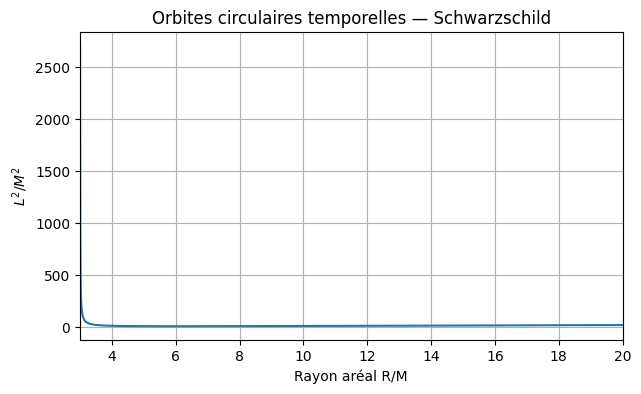

In [11]:

rho_grid = np.linspace(0.55, 30.0, 5000)
circ_rows = []

for rho in rho_grid:
    E2, L2 = circular_EL2(rho, "schwarzschild")
    if np.isfinite(E2) and np.isfinite(L2) and E2 > 0 and L2 > 0:
        circ_rows.append((rho, areal_radius(rho, "schwarzschild"), E2, L2))

circ_df = pd.DataFrame(circ_rows, columns=["rho","R_areal","E2","L2"])

plt.figure(figsize=(7,4))
plt.plot(circ_df["R_areal"], circ_df["L2"])
plt.xlim(3,20)
plt.xlabel("Rayon aréal R/M")
plt.ylabel(r"$L^2/M^2$")
plt.title("Orbites circulaires temporelles — Schwarzschild")
plt.grid(True)
plt.show()



# 10. Recherche de l'ISCO

Nous minimisons \(L^2(\rho)\) dans la branche physique située au-delà de la sphère photonique.

Pour Schwarzschild, la référence est :

\[
R_{\mathrm{ISCO}}=6M.
\]


In [12]:

rho_ph_s = photon_df.loc[0, "rho_photon"]

result_isco = minimize_scalar(
    lambda rr: circular_EL2(rr, "schwarzschild")[1],
    bounds=(rho_ph_s*1.02, 20.0),
    method="bounded",
    options={"xatol": 1e-11}
)

rho_isco_s = result_isco.x
R_isco_s = areal_radius(rho_isco_s, "schwarzschild")
E2_isco_s, L2_isco_s = circular_EL2(rho_isco_s, "schwarzschild")

isco_df = pd.DataFrame([{
    "model": "Schwarzschild",
    "rho_ISCO": rho_isco_s,
    "R_areal_ISCO": R_isco_s,
    "E_ISCO": np.sqrt(E2_isco_s),
    "L_ISCO": np.sqrt(L2_isco_s),
    "relative_error_R_vs_6M": abs(R_isco_s-6.0)/6.0
}])

isco_df


,model,rho_ISCO,R_areal_ISCO,E_ISCO,L_ISCO,relative_error_R_vs_6M
0,Schwarzschild,4.949518,6.000028,0.942809,3.464102,0.000005



# 11. Comparaison avec le candidat GVH

Nous calculons pour le même candidat :

- racines de sphère photonique ;
- rayon aréal correspondant ;
- paramètre d'impact critique optique ;
- ISCO éventuel ;
- domaine où \(A>0\) et \(B>0\).

Une absence de racine ou une perte de positivité doit être signalée, pas masquée.


In [13]:

photon_roots_g = find_photon_sphere("gvh", CANDIDATE, bracket=(0.55, 30.0))

gvh_photon_rows = []
for rho_ph in photon_roots_g:
    A_ph, B_ph = metric_AB(rho_ph, "gvh", CANDIDATE)
    gvh_photon_rows.append({
        "rho_photon": rho_ph,
        "R_areal": areal_radius(rho_ph, "gvh", CANDIDATE),
        "b_critical": np.sqrt(optical_impact_squared(rho_ph, "gvh", CANDIDATE)),
        "A": A_ph,
        "B": B_ph
    })

gvh_photon_df = pd.DataFrame(gvh_photon_rows)
gvh_photon_df


,rho_photon,R_areal,b_critical,A,B
0,2.27692,3.384938,5.488751,0.380324,2.210068


In [14]:

gvh_isco_result = None
gvh_isco_row = None

if len(photon_roots_g) > 0:
    lower = max(photon_roots_g)*1.02

    def safe_L2(rr):
        E2, L2 = circular_EL2(rr, "gvh", CANDIDATE)
        if not np.isfinite(L2) or L2 <= 0:
            return 1e12
        return L2

    trial = minimize_scalar(
        safe_L2,
        bounds=(lower, 50.0),
        method="bounded"
    )

    if trial.success and trial.fun < 1e11:
        rho_isco_g = trial.x
        R_isco_g = areal_radius(rho_isco_g, "gvh", CANDIDATE)
        E2_g, L2_g = circular_EL2(rho_isco_g, "gvh", CANDIDATE)

        gvh_isco_row = {
            "model": "GVH candidate",
            "rho_ISCO": rho_isco_g,
            "R_areal_ISCO": R_isco_g,
            "E_ISCO": np.sqrt(E2_g),
            "L_ISCO": np.sqrt(L2_g)
        }

pd.DataFrame([gvh_isco_row]) if gvh_isco_row else pd.DataFrame()


,model,rho_ISCO,R_areal_ISCO,E_ISCO,L_ISCO
0,GVH candidate,5.305388,6.352336,0.944975,3.510812



# 12. Cartographie capture / évasion pour Schwarzschild et GVH

Nous balayons plusieurs paramètres d'impact et construisons une classification opérationnelle.

Le résultat permet de visualiser un éventuel déplacement du seuil critique.


In [15]:

impact_grid = np.linspace(3.5, 8.0, 24)
classification_rows = []

for model in ["schwarzschild", "gvh"]:
    for b in impact_grid:
        try:
            sol, status = integrate_null_ray(
                b,
                model=model,
                params=CANDIDATE,
                lambda_max=350.0,
                r_escape=90.0
            )
            rho_min = np.min(np.linalg.norm(sol.y[1:4].T, axis=1))
        except Exception as exc:
            status = "invalid"
            rho_min = np.nan

        classification_rows.append({
            "model": model,
            "b": b,
            "status": status,
            "rho_min": rho_min
        })

classification_df = pd.DataFrame(classification_rows)
classification_df.head()


,model,b,status,rho_min
0,schwarzschild,3.500000,capture,0.51
1,schwarzschild,3.695652,capture,0.51
2,schwarzschild,3.891304,capture,0.51
3,schwarzschild,4.086957,capture,0.51
4,schwarzschild,4.282609,capture,0.51


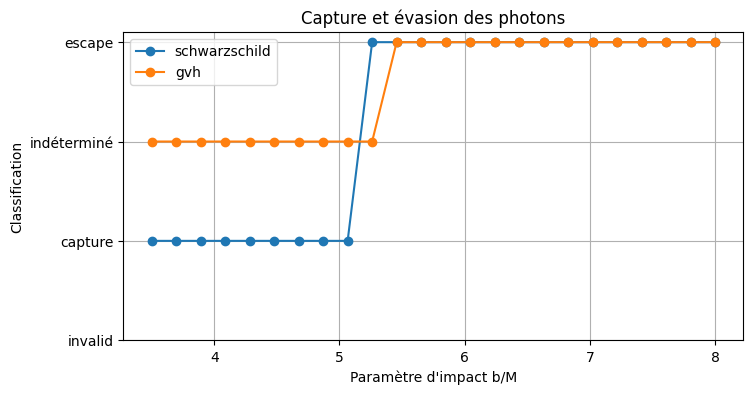

In [16]:

status_map = {"capture":0, "undetermined":1, "escape":2, "invalid":-1}

plt.figure(figsize=(8,4))
for model in ["schwarzschild","gvh"]:
    subset = classification_df[classification_df["model"]==model]
    yvals = [status_map[s] for s in subset["status"]]
    plt.plot(subset["b"], yvals, "o-", label=model)

plt.yticks(
    [-1,0,1,2],
    ["invalid","capture","indéterminé","escape"]
)
plt.xlabel("Paramètre d'impact b/M")
plt.ylabel("Classification")
plt.title("Capture et évasion des photons")
plt.grid(True)
plt.legend()
plt.show()



# 13. Conservation de la condition nulle

Pour chaque trajectoire photonique :

\[
\mathcal N
=
g_{\mu\nu}U^\mu U^\nu
\]

doit rester proche de zéro.

Nous évaluons la dérive maximale sur une trajectoire diffusée.


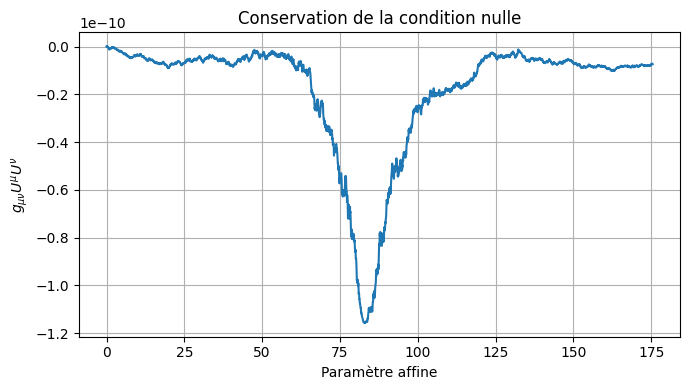

Statut : escape
Dérive maximale absolue : 1.1571454905379142e-10


In [18]:
sol_test_null, status_test_null = integrate_null_ray(
    6.5,
    model="schwarzschild",
    lambda_max=300.0
)

null_values = np.array([
    null_norm(
        sol_test_null.y[:, k],
        model="schwarzschild"
    )
    for k in range(sol_test_null.y.shape[1])
])

null_drift_max = np.max(np.abs(null_values))

plt.figure(figsize=(7, 4))

plt.plot(
    sol_test_null.t,
    null_values
)

plt.xlabel("Paramètre affine")

plt.ylabel(
    r"$g_{\mu\nu}U^\mu U^\nu$"
)

plt.title(
    "Conservation de la condition nulle"
)

plt.grid(True)
plt.tight_layout()
plt.show()

print("Statut :", status_test_null)
print("Dérive maximale absolue :", null_drift_max)


# 14. Tableau de validation

Les tests critiques sont :

- récupération de \(b_{\mathrm{crit}}=3\sqrt3M\) ;
- récupération de \(R_{\mathrm{ph}}=3M\) ;
- récupération de \(R_{\mathrm{ISCO}}=6M\) ;
- conservation de la condition nulle ;
- classification cohérente capture/évasion ;
- métrique candidate positive dans son domaine analysé.


In [ ]:

photon_R_s = photon_df.loc[0, "R_areal"]
photon_b_s = photon_df.loc[0, "b_critical"]

validation_rows = [
    {
        "test": "Impact critique Schwarzschild",
        "value": abs(bcrit_num-bcrit_ref)/bcrit_ref,
        "threshold": 5e-3
    },
    {
        "test": "Sphère photonique R=3M",
        "value": abs(photon_R_s-3.0)/3.0,
        "threshold": 1e-5
    },
    {
        "test": "Impact optique 3sqrt(3)M",
        "value": abs(photon_b_s-bcrit_ref)/bcrit_ref,
        "threshold": 1e-5
    },
    {
        "test": "ISCO R=6M",
        "value": abs(R_isco_s-6.0)/6.0,
        "threshold": 1e-4
    },
    {
        "test": "Conservation géodésique nulle",
        "value": null_drift_max,
        "threshold": 1e-6
    }
]

validation_df = pd.DataFrame(validation_rows)
validation_df["status"] = np.where(
    validation_df["value"] <= validation_df["threshold"],
    "PASS",
    "CHECK"
)
validation_df



# 15. Résumé Schwarzschild / GVH

Le tableau suivant rassemble les observables fortes principales.

Une différence n'est scientifiquement intéressante que si elle est :

1. stable numériquement ;
2. indépendante du système de coordonnées ;
3. compatible avec les tests faibles ;
4. reliée à une métrique GVH dérivée ;
5. potentiellement observable.


In [ ]:

summary_rows = [{
    "model": "Schwarzschild",
    "rho_photon": photon_df.loc[0, "rho_photon"],
    "R_photon": photon_df.loc[0, "R_areal"],
    "b_critical": photon_df.loc[0, "b_critical"],
    "rho_ISCO": rho_isco_s,
    "R_ISCO": R_isco_s
}]

if len(gvh_photon_df) > 0:
    row = {
        "model": "GVH candidate",
        "rho_photon": gvh_photon_df.iloc[0]["rho_photon"],
        "R_photon": gvh_photon_df.iloc[0]["R_areal"],
        "b_critical": gvh_photon_df.iloc[0]["b_critical"],
        "rho_ISCO": np.nan,
        "R_ISCO": np.nan
    }
    if gvh_isco_row:
        row["rho_ISCO"] = gvh_isco_row["rho_ISCO"]
        row["R_ISCO"] = gvh_isco_row["R_areal_ISCO"]
    summary_rows.append(row)

strong_field_summary = pd.DataFrame(summary_rows)
strong_field_summary



# 16. Export des résultats

Les résultats sont exportés pour comparaison avec les versions futures.


In [ ]:

import json
from pathlib import Path

summary_path = Path("GVH_Diagonal_Cubic_0.2.6_Strong_Field_Summary.csv")
validation_path = Path("GVH_Diagonal_Cubic_0.2.6_Validation.csv")
classification_path = Path("GVH_Diagonal_Cubic_0.2.6_Capture_Escape_Map.csv")
metadata_path = Path("GVH_Diagonal_Cubic_0.2.6_Metadata.json")

strong_field_summary.to_csv(summary_path, index=False)
validation_df.to_csv(validation_path, index=False)
classification_df.to_csv(classification_path, index=False)

metadata = {
    "candidate": CANDIDATE,
    "bcrit_numeric_schwarzschild": float(bcrit_num),
    "bcrit_reference": float(bcrit_ref),
    "R_photon_schwarzschild": float(photon_R_s),
    "R_ISCO_schwarzschild": float(R_isco_s),
    "null_drift_max": float(null_drift_max)
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Exports terminés :")
print(summary_path)
print(validation_path)
print(classification_path)
print(metadata_path)



# 17. Interprétation scientifique

## Résultats de référence attendus

Pour Schwarzschild :

\[
R_{\mathrm{ph}}=3M,
\]

\[
b_{\mathrm{crit}}=3\sqrt3M,
\]

\[
R_{\mathrm{ISCO}}=6M.
\]

La reproduction numérique de ces valeurs valide l'infrastructure de champ fort.

## Interprétation du candidat GVH

Trois cas sont possibles :

### 1. Résultats identiques à Schwarzschild

Le candidat est probablement une approximation ou une reformulation de Schwarzschild dans le domaine étudié.

### 2. Résultats proches mais différents

La différence doit être confrontée aux observations et à la stabilité du modèle.

### 3. Absence d'horizon, de sphère photonique ou d'ISCO physique

Le candidat peut être incompatible avec les objets compacts connus, ou seulement utilisé hors de son domaine de validité.

Aucune conclusion ne doit être tirée d'un développement polynomial extrapolé au champ fort sans justification.



# 18. Conclusion

Cette version étend le pipeline GVH aux signatures de champ fort :

\[
g_{\mu\nu}
\longrightarrow
\Gamma^\mu_{\alpha\beta}
\longrightarrow
\text{géodésiques nulles et temporelles}
\longrightarrow
\text{capture, sphère photonique, ISCO}.
\]

Les résultats principaux sont :

1. intégration de photons dans la métrique isotrope ;
2. classification capture / évasion ;
3. recherche de \(b_{\mathrm{crit}}\) ;
4. calcul de la sphère photonique ;
5. calcul des orbites circulaires temporelles ;
6. estimation de l'ISCO ;
7. comparaison Schwarzschild / candidat GVH ;
8. validation de la condition nulle ;
9. export des indicateurs.

---

## Étape suivante proposée

\[
\boxed{
\texttt{GVH\_Diagonal\_Cubic\_0.2.7\_Covariance\_Curvature\_Invariants.ipynb}
}
\]

Elle devra calculer :

- tenseur de Riemann ;
- tenseur de Ricci ;
- scalaire de Ricci ;
- tenseur d'Einstein ;
- invariant de Kretschmann ;
- tests de rotation et de changement de coordonnées ;
- distinction entre courbure réelle et effets de coordonnées.
